# COGS 109 — Analysis
## Difference-in-Differences, COVID Controls, Event Study, and a Selection Classifier

This notebook documents **what the models found** on the national panel and how to read each
result. It is a reading aid for the human writers — it explains the findings and shows the figures;
it does not write the paper. Numbers and figures are loaded from `results_national/`, which was
produced by `scripts/national/fit_models_national.py` and `fit_classifier.py`.

**Sample:** the DiD set — 150 counties (26 in-panel treated + 124 control), 2010–2024.
**Outcomes:** residential electricity rate, unemployment rate, per-capita income.
**Treatment:** `dc_active` = 1 from each county's data-center opening year onward (staggered).

---

### The one-sentence result
On the national panel, the electricity effect of a data center **attenuates to about +0.15 ¢/kWh
and is no longer statistically distinguishable from zero** — and adding explicit COVID controls
barely changes it, so the (weak) effect is **not** a pandemic artifact.

## The five specifications

Each model adds controls on top of the last. All are fit on a **common sample per outcome** (the
same rows for M1–M5, so cross-validated error is comparable), with **county + year fixed effects**
built on the sample, the outcome removed from its own predictor list, and **cluster-robust standard
errors** clustered on county.

| Spec | Controls added |
|---|---|
| **M1** | `dc_active` + year FE + state FE |
| **M2** | + economic controls (income, log employment, wage, electricity rate) |
| **M3** | + demographic controls (poverty, unemployment, log density, age, % bachelor's) |
| **M3+C** | **+ COVID controls (covid_deaths_per_100k, wfh_rate)** — the key new spec |
| **M4 / M5** | M3 predictors with Lasso / Ridge regularization |

Model selection uses 10-fold `GroupKFold` cross-validation grouped on county; the treatment
*estimate* always comes from the cluster-robust OLS fit (not the regularized path).

In [1]:
import pandas as pd, numpy as np
ct = pd.read_csv('results_national/comparison_table.csv')

# electricity: all specs side by side
e = ct[ct.outcome=='elec_rate_cents_kwh'][
    ['model','n_obs','dc_active_coef_ols','dc_active_ci_lo_ols','dc_active_ci_hi_ols',
     'dc_active_boot_lo','dc_active_boot_hi','cv_rmse']].copy()
e.columns = ['model','n','coef','ci_lo','ci_hi','boot_lo','boot_hi','cv_rmse']
print('ELECTRICITY RATE (cents/kWh) — dc_active across specifications:')
print(e.round(3).to_string(index=False))
print('\nEvery CI spans 0 -> the national electricity effect is not distinguishable from zero.')
print('Cluster-robust and bootstrap CIs agree closely (course-aligned inference check).')

ELECTRICITY RATE (cents/kWh) — dc_active across specifications:
model    n  coef  ci_lo  ci_hi  boot_lo  boot_hi  cv_rmse
   M1 1614 0.073 -0.336  0.482   -0.314    0.506    1.130
   M2 1614 0.105 -0.306  0.516   -0.286    0.522    1.132
   M3 1614 0.154 -0.268  0.576   -0.276    0.605    1.145
 M3+C 1614 0.138 -0.290  0.567   -0.318    0.605    1.145
   M4 1614 0.154 -0.268  0.576   -0.277    0.612    1.130
   M5 1614 0.154 -0.268  0.576   -0.318    0.576    1.134

Every CI spans 0 -> the national electricity effect is not distinguishable from zero.
Cluster-robust and bootstrap CIs agree closely (course-aligned inference check).


## The COVID test — M3 vs M3+C (the headline of this phase)

The single most important comparison: does the `dc_active` electricity coefficient move when we add
**explicit** COVID controls (deaths per 100k + work-from-home rate)? If it barely moves, the effect
is not a pandemic artifact.

Because the electricity sample already ends in 2022 (the EIA data gap), COVID and WFH have **zero**
missing values inside that frame — so M3 and M3+C are fit on the **identical 1,614 rows**. This is
the cleanest possible version of the test: same data, only the COVID controls differ.

In [2]:
m3  = e[e.model=='M3'].iloc[0]
m3c = e[e.model=='M3+C'].iloc[0]
pct = 100*(m3c.coef - m3.coef)/abs(m3.coef)
print(f'M3   electricity dc_active: {m3.coef:+.3f} c/kWh   CI [{m3.ci_lo:.3f}, {m3.ci_hi:.3f}]   n={int(m3.n)}')
print(f'M3+C electricity dc_active: {m3c.coef:+.3f} c/kWh   CI [{m3c.ci_lo:.3f}, {m3c.ci_hi:.3f}]   n={int(m3c.n)}')
print(f'\nChange when COVID controls added: {pct:+.1f}%')
print('Adding COVID deaths + WFH barely moves the coefficient ->')
print('the (weak) electricity effect is NOT explained by the pandemic.')

M3   electricity dc_active: +0.154 c/kWh   CI [-0.268, 0.576]   n=1614
M3+C electricity dc_active: +0.138 c/kWh   CI [-0.290, 0.567]   n=1614

Change when COVID controls added: -10.3%
Adding COVID deaths + WFH barely moves the coefficient ->
the (weak) electricity effect is NOT explained by the pandemic.


### Treatment effect across all specifications and outcomes

The forest plot below shows `dc_active` with cluster-robust 95% CIs for every spec and all three
outcomes. The M3 and M3+C markers (gray vs **green**) sit almost on top of each other in all three
panels — visual proof that COVID controls don't move the estimate. Only one marker excludes zero
(per-capita income, M2), and it isn't robust across specs.

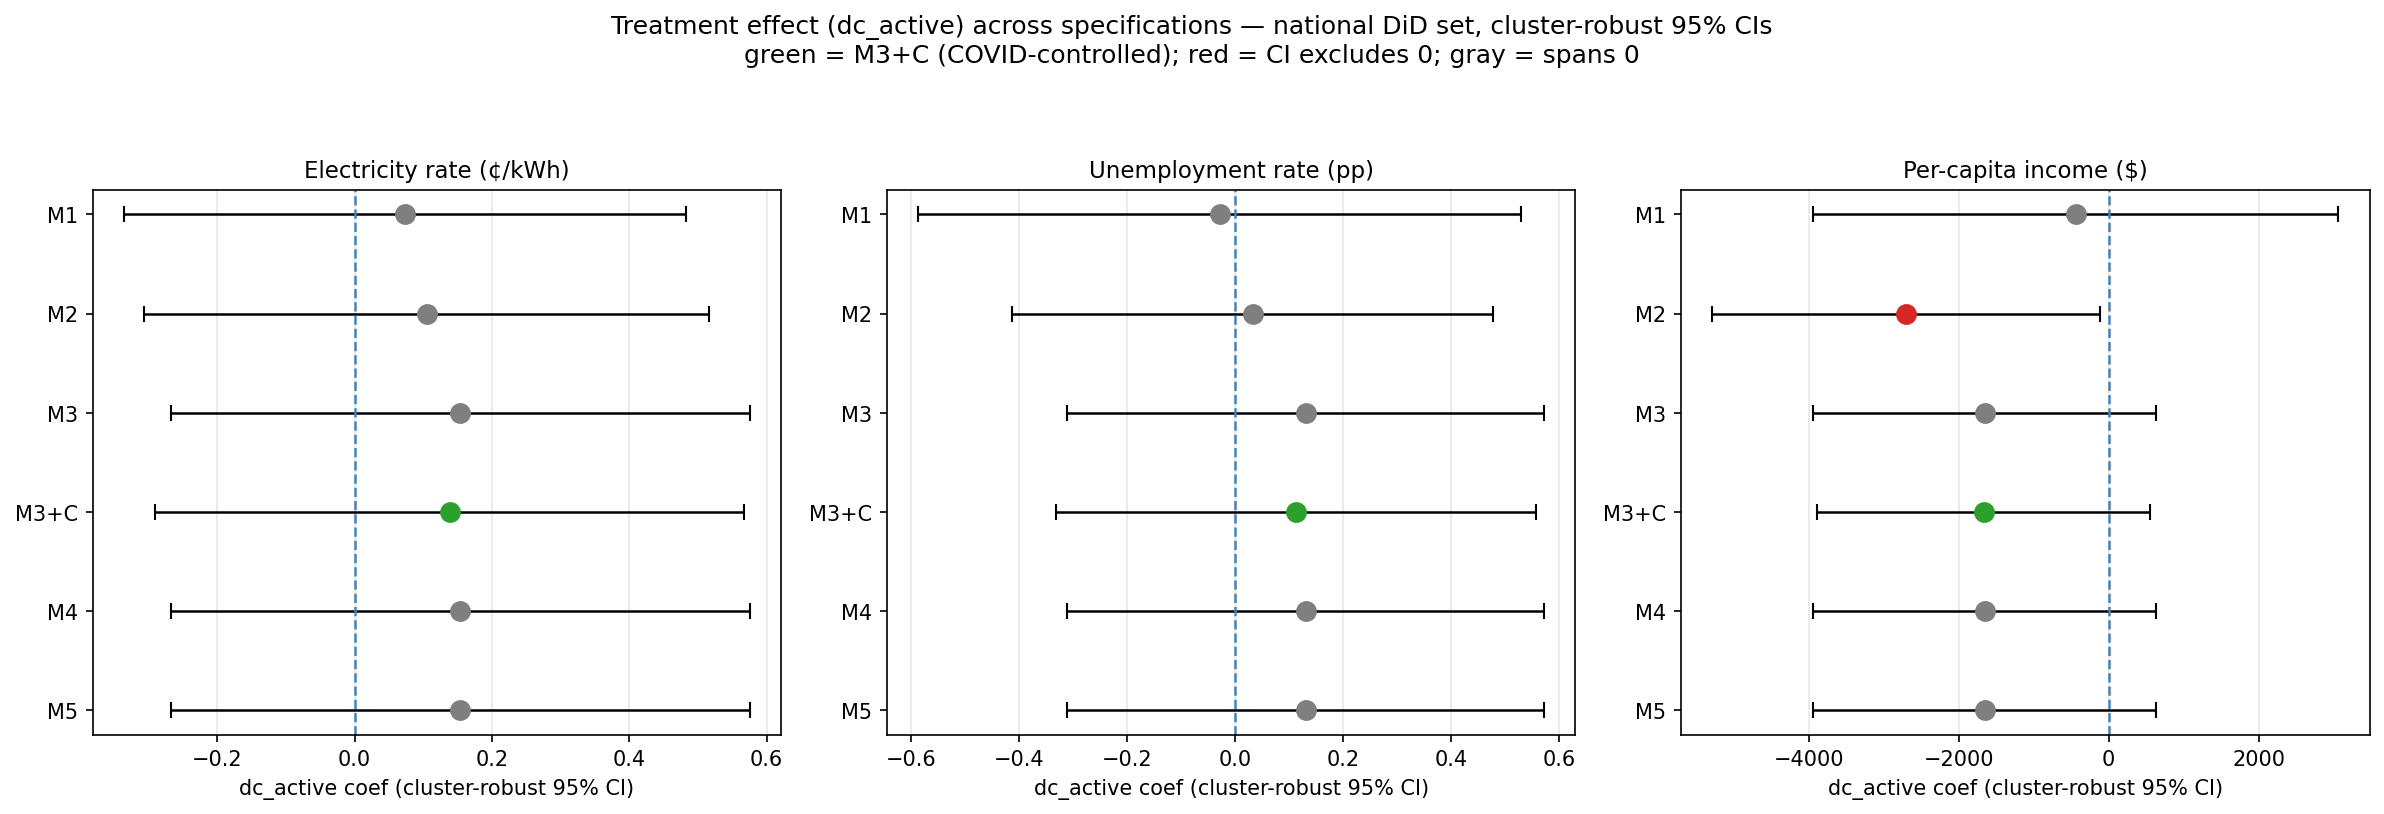

In [3]:
from IPython.display import Image
Image('results_national/dc_active_forest_plot.png')

## Event study — testing parallel pre-trends

A difference-in-differences result is only credible if treated and control counties were on
**parallel paths before** treatment. The event study replaces the single `dc_active` switch with
dummies for each year **relative to a county's opening** (−1, the year before opening, is the
omitted reference). If the pre-opening coefficients (−3, −2) are near zero, parallel pre-trends
hold and the design is defensible.

Read the plot below left-to-right: the **left half (pre-opening) is flat and near zero** — pre-trends
hold — and the effect rises gradually *after* opening (peaking around +2 years), though every CI
still spans zero at national scale. The gradual ramp also answers the "when does it start?" question:
effects emerge over several years, not at one sharp date.

Event-study coefficients (electricity, relative to opening year):
     bin   coef     lo    hi
     ≤-4 -0.118 -0.649 0.413
      -3 -0.090 -0.498 0.319
      -2 -0.059 -0.485 0.367
-1 (ref)  0.000  0.000 0.000
       0  0.015 -0.353 0.383
      +1  0.131 -0.297 0.558
      +2  0.338 -0.142 0.817
      +3  0.100 -0.415 0.615
     ≥+4  0.155 -0.412 0.721

Pre-trend coefficients (t=-3, t=-2): [-0.09, -0.059] -> small, near zero.
Parallel pre-trends are defensible.


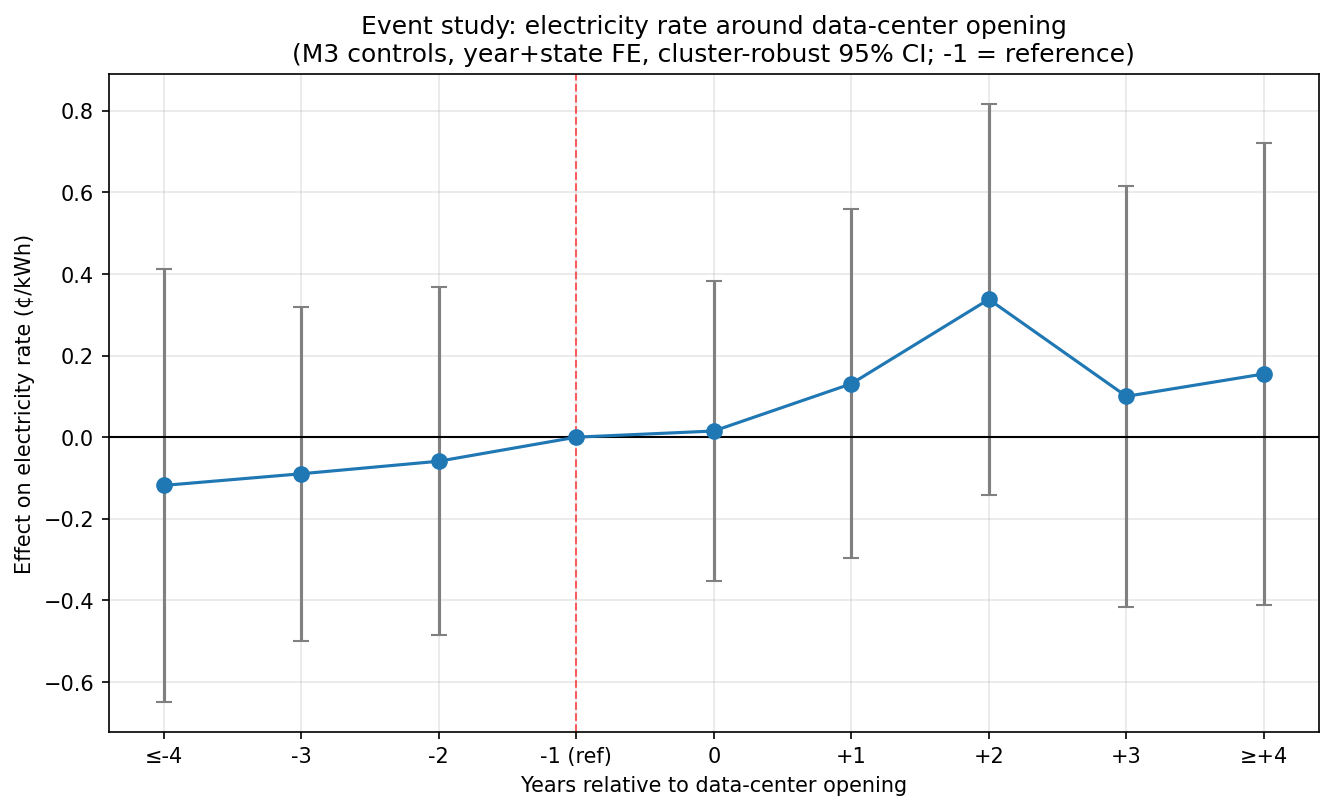

In [4]:
es = pd.read_csv('results_national/event_study_coefs.csv')
print('Event-study coefficients (electricity, relative to opening year):')
print(es.round(3).to_string(index=False))
pre = es[es.bin.isin(['-3','-2'])]
print(f'\nPre-trend coefficients (t=-3, t=-2): {pre.coef.round(3).tolist()} -> small, near zero.')
print('Parallel pre-trends are defensible.')
Image('results_national/event_study_electricity.png')

## Winners and robustness

The cross-validation winner per outcome, plus two quick robustness checks on the electricity result:
re-coding Licking County's opening (AWS 2016 vs Meta 2020), and dropping the 29 controls that
attracted a data center *after* the panel. The full text is in
`results_national/winner_summary.md` and `covid_robustness.md`.

In [5]:
for oc in ['elec_rate_cents_kwh','unemployment_rate','per_capita_income']:
    w = ct[(ct.outcome==oc) & (ct.is_winner==True)].iloc[0]
    print(f'{oc:24s} winner: {w.model:4s}  CV-RMSE={w.cv_rmse:.4g}  dc_active={w.dc_active_coef_ols:+.4g}')
print('\nElectricity robustness (from winner_summary.md):')
print('  Licking 2016 vs 2020:  effect moves ~0.005 c/kWh  -> result does NOT hinge on the date')
print('  Drop 29 future-DC ctrls: effect moves ~0.07 c/kWh  -> stable')

elec_rate_cents_kwh      winner: M1    CV-RMSE=1.13  dc_active=+0.07311
unemployment_rate        winner: M3    CV-RMSE=1.676  dc_active=+0.1309
per_capita_income        winner: M5    CV-RMSE=7600  dc_active=-1654

Electricity robustness (from winner_summary.md):
  Licking 2016 vs 2020:  effect moves ~0.005 c/kWh  -> result does NOT hinge on the date
  Drop 29 future-DC ctrls: effect moves ~0.07 c/kWh  -> stable


## Phase 5 — Can baseline covariates tell DC counties apart? (the selection classifier)

Prof. Mukamel suggested a classifier at the poster session: using only **pre-treatment (2010–2012)**
county characteristics, can we predict which counties will get a data center? The idea is that if DC
counties are systematically different on observables, that "selection" matters for interpretation —
and because both DC and control counties lived through COVID, any such signal is **COVID-independent**.

Two course-scope models only: **logistic regression** and **KNN** (K tuned by CV). Label =
`classifier_dc` (39 positives vs 130 negatives, base rate 23%). Stratified 10-fold CV, seed 42.

                   model      params  cv_auc  cv_accuracy
                Logistic unpenalized   0.588        0.782
                     KNN        K=10   0.592        0.775
Baseline (predict no-DC)           -   0.500        0.769

Both models land near AUC 0.59 -- barely above chance (0.5).
Winner accuracy equals the base-rate baseline: it is essentially predicting "no DC" for all.


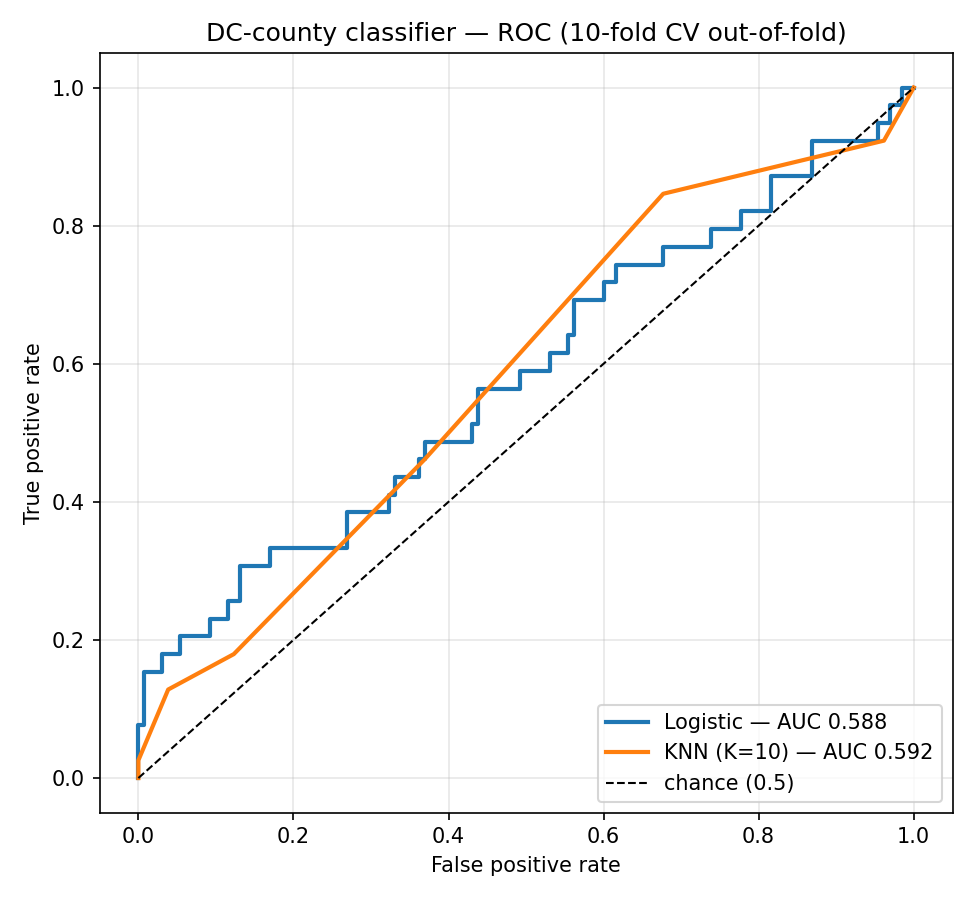

In [6]:
cc = pd.read_csv('results_national/classifier_comparison.csv')
print(cc.round(3).to_string(index=False))
print('\nBoth models land near AUC 0.59 -- barely above chance (0.5).')
print('Winner accuracy equals the base-rate baseline: it is essentially predicting "no DC" for all.')
Image('results_national/classifier_roc.png')

### How to read the classifier — the honest version

The classifier comes back **near chance (AUC ≈ 0.59, bootstrap CI includes 0.5; accuracy = base
rate)**. This is *not* the strong "DC counties are obviously different" result one might expect, and
the reason is important and two-sided:

1. **The controls were deliberately matched** in Phase 2 — same state, same population band. Matching
   mechanically removes the two strongest natural separators (county **size** and **region**) *before*
   the classifier runs. So a low AUC partly means **the matching worked**, not that no selection exists.
   Against an unmatched random-county pool, the AUC would almost certainly be much higher.
2. With n = 169 and 9 features, any faint residual selection is hard to detect anyway.

**What it means for the paper:** within the matched design, residual cross-sectional selection on
observables is weak, so identification rests on the **within-county DiD comparison**, not on
cross-sectional contrasts. Because both classes experienced COVID, this is a COVID-independent
statement — consistent with the M3+C result. The classifier is **corroborating context, not a
causal estimator**; inference stays with the regression. The two robustness reruns (dropping the
always-treated extremes, dropping the future-DC controls) stay near chance, so the near-null is stable.

The full write-up, coefficients, and the K-tuning and confusion figures are in
`results_national/classifier_summary.md`.